
K = 1
Accuracy: 0.9666666666666667


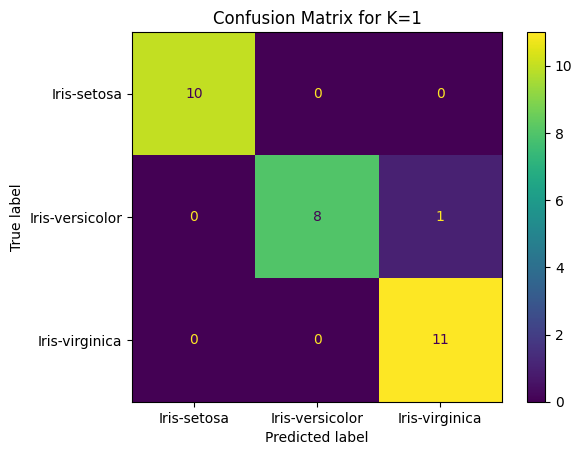


K = 3
Accuracy: 1.0


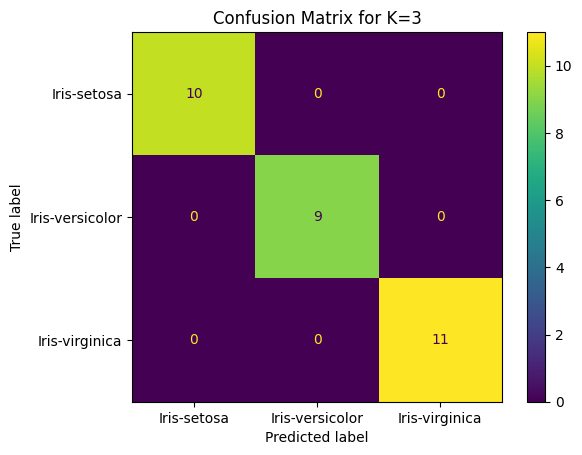


K = 5
Accuracy: 1.0


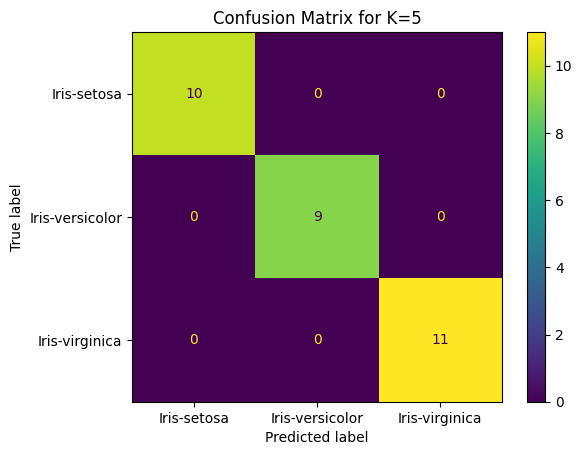


K = 7
Accuracy: 1.0


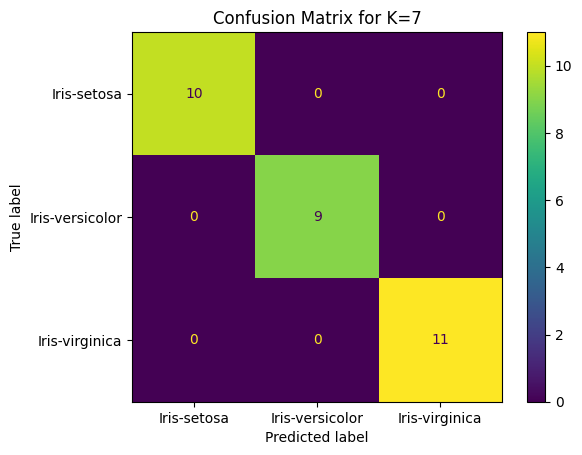

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

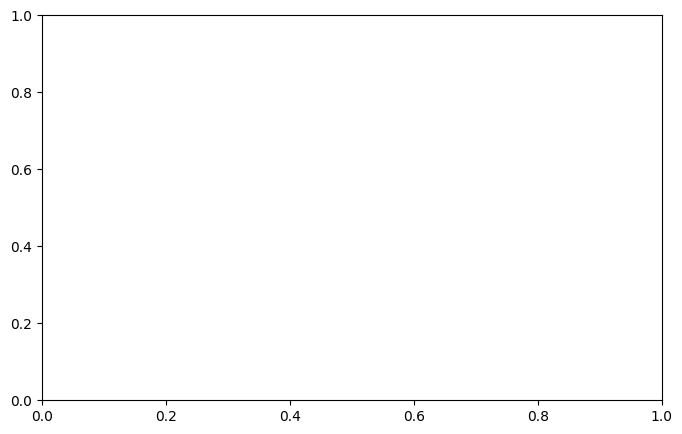

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

# Step 1: Load the dataset
path = r"C:\Users\TANYA\OneDrive\Desktop\archive\Iris.csv"
df = pd.read_csv(path)

# Drop ID column if exists
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Step 2: Separate features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 3: Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Try different values of k
for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nK = {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot()
    plt.title(f"Confusion Matrix for K={k}")
    plt.show()

# Step 6: Visualization (using first 2 features only)
X_vis = X_scaled[:, :2]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_vis, y_train_vis)

# Create mesh grid
h = .02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=[['red', 'green', 'blue'][['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'].index(i)] for i in y], edgecolor='k', s=20)
plt.title("KNN Decision Boundaries (K=3)")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()
